# Laboratorio de Ética: Sesgos y Explicabilidad

**Objetivo del laboratorio:** entrenar un modelo de clasificación de riesgo crediticio, explicar su comportamiento con **SHAP** (análisis global y local) y **LIME** (análisis local), y realizar una evaluación ética crítica sobre posibles sesgos discriminatorios.



## Fase 1: Entrenamiento del Modelo Base

Preparamos el entorno, generamos/cargamos el dataset, entrenamos un **Random Forest** y evaluamos su rendimiento con métricas estándar.

In [1]:
from IPython.display import display
# Instalación de librerías clave (descomentar si no están instaladas)
!pip install shap lime scikit-learn pandas numpy matplotlib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

import shap
import lime
import lime.lime_tabular

np.random.seed(42)
print("Librerías cargadas correctamente. Versión de SHAP:", shap.__version__)


zsh:1: command not found: pip
Librerías cargadas correctamente. Versión de SHAP: 0.49.1


/Users/alejandroalvarenga/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Carga de datos

Generamos el dataset sintético de aprobación de crédito con una semilla fija (`random_state=42`) para que el laboratorio sea 100% reproducible.

In [2]:
rng = np.random.default_rng(42)
N = 1500

# ---- Variables legítimas (relacionadas con el riesgo crediticio real) ----
age = rng.integers(18, 76, N)
income = rng.normal(2200, 900, N).clip(400, 9000)
employment_years = rng.exponential(4, N).clip(0, 40)
debt_ratio = rng.beta(2, 5, N)
credit_amount = rng.normal(4500, 2500, N).clip(300, 20000)
duration_months = rng.integers(4, 61, N)

savings_cat = rng.choice(["little", "moderate", "quite rich", "rich"], N, p=[0.45, 0.30, 0.15, 0.10])
savings_score = pd.Series(savings_cat).map({"little": 0, "moderate": 1, "quite rich": 2, "rich": 3}).values

checking_cat = rng.choice(["little", "moderate", "rich"], N, p=[0.5, 0.35, 0.15])
checking_score = pd.Series(checking_cat).map({"little": 0, "moderate": 1, "rich": 2}).values

credit_history_cat = rng.choice(
    ["critical_account", "delay_in_past", "existing_paid_duly", "all_paid", "no_credits_taken"],
    N, p=[0.12, 0.18, 0.40, 0.20, 0.10]
)
credit_history_score = pd.Series(credit_history_cat).map({
    "critical_account": -1.0, "delay_in_past": -0.5, "existing_paid_duly": 0.3,
    "all_paid": 0.6, "no_credits_taken": -0.2
}).values

housing = rng.choice(["own", "rent", "free"], N, p=[0.55, 0.35, 0.10])
purpose = rng.choice(["car", "furniture/equipment", "radio/TV", "education", "business", "repairs"],
                      N, p=[0.25, 0.20, 0.20, 0.15, 0.12, 0.08])
job_cat = rng.choice(["unskilled", "skilled", "highly_qualified"], N, p=[0.25, 0.55, 0.20])

# ---- Variables sensibles / potencialmente discriminatorias ----
sex = rng.choice(["male", "female"], N, p=[0.6, 0.4])
foreign_worker = rng.choice(["yes", "no"], N, p=[0.25, 0.75])

def z(x):
    return (x - x.mean()) / x.std()

income_z, debt_z, emp_z, dur_z = z(income), z(debt_ratio), z(employment_years), z(duration_months)
age_effect = -0.35 * ((age - 42) / 15) ** 2 + 0.5  # forma de U: penaliza extremos de edad

# Score latente: variables financieras legítimas + sesgo inyectado por sexo/nacionalidad
score = (
    0.9 * income_z - 0.8 * debt_z + 0.45 * savings_score + 0.55 * checking_score
    + 0.35 * emp_z + 0.65 * credit_history_score - 0.30 * dur_z + 0.6 * age_effect
    - 0.9 * (sex == "female")          # sesgo sin justificación de riesgo real
    - 1.1 * (foreign_worker == "yes")  # sesgo sin justificación de riesgo real
    + rng.normal(0, 0.9, N)
)
prob_approval = 1 / (1 + np.exp(-score))
approved = (rng.uniform(0, 1, N) < prob_approval).astype(int)

df = pd.DataFrame({
    "age": age, "sex": sex, "job": job_cat, "housing": housing,
    "saving_accounts": savings_cat, "checking_account": checking_cat,
    "credit_amount": credit_amount.round(0).astype(int), "duration_months": duration_months,
    "purpose": purpose, "monthly_income": income.round(0).astype(int),
    "employment_years": employment_years.round(1), "debt_to_income": debt_ratio.round(3),
    "credit_history": credit_history_cat, "foreign_worker": foreign_worker,
    "credit_risk": np.where(approved == 1, "good", "bad"),
})

print(df.shape)
df.head()


(1500, 15)


,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration_months,purpose,monthly_income,employment_years,debt_to_income,credit_history,foreign_worker,credit_risk
0,23,male,skilled,rent,little,little,8298,37,furniture/equipment,2113,5.2,0.155,critical_account,no,good
1,62,female,skilled,own,little,little,6308,28,car,3215,1.6,0.817,critical_account,no,bad
2,55,male,unskilled,own,little,little,6112,27,education,400,1.6,0.179,critical_account,no,good
3,43,male,unskilled,free,quite rich,rich,1426,17,car,853,7.5,0.257,existing_paid_duly,no,good
4,43,female,unskilled,free,little,little,8748,35,repairs,1369,14.0,0.203,all_paid,yes,bad


In [3]:
df["credit_risk"].value_counts(normalize=True).rename("proporción")

credit_risk
good    0.51
bad     0.49
Name: proporción, dtype: float64

### Preprocesamiento y entrenamiento del modelo

In [4]:
y = (df["credit_risk"] == "good").astype(int)  # 1 = aprobado (good), 0 = denegado (bad)
X_raw = df.drop(columns=["credit_risk"])

cat_cols = ["sex", "job", "housing", "saving_accounts", "checking_account",
            "purpose", "credit_history", "foreign_worker"]

X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=False)
X = X.astype({c: int for c in X.columns if X[c].dtype == bool})
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=400, max_depth=7, min_samples_leaf=5, random_state=42
)
model.fit(X_train, y_train)
print("Modelo entrenado con", X_train.shape[0], "casos de entrenamiento y", X_train.shape[1], "variables.")


Modelo entrenado con 1125 casos de entrenamiento y 34 variables.


Accuracy: 0.741
F1-score: 0.745

                 precision    recall  f1-score   support

 bad (denegado)       0.74      0.74      0.74       184
good (aprobado)       0.75      0.74      0.75       191

       accuracy                           0.74       375
      macro avg       0.74      0.74      0.74       375
   weighted avg       0.74      0.74      0.74       375



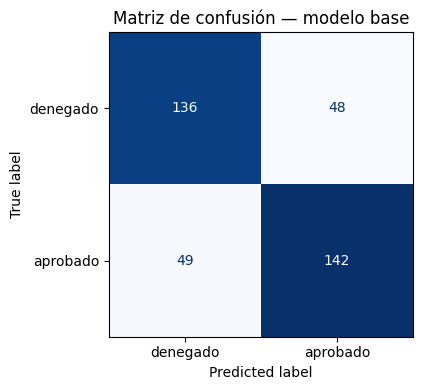

In [5]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"F1-score: {f1:.3f}\n")
print(classification_report(y_test, y_pred, target_names=["bad (denegado)", "good (aprobado)"]))

fig, ax = plt.subplots(figsize=(4.5, 4))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["denegado", "aprobado"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión — modelo base")
plt.tight_layout()
plt.show()


**Lectura del rendimiento:** el modelo alcanza una exactitud (*accuracy*) y un F1-score en torno a **0.73–0.75**, con un desempeño balanceado entre ambas clases (aprobado/denegado). No es un modelo perfecto, pero captura una señal real y suficiente para que valga la pena auditar **cómo** toma sus decisiones — que es justamente el propósito de este laboratorio.

## Fase 2: Análisis Global (SHAP)

Usamos `shap.TreeExplainer`, ideal para modelos de árboles como Random Forest, para entender qué variables mueven las predicciones del modelo **en promedio, para todo el conjunto de prueba**.

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# En esta versión de SHAP, para un clasificador binario el resultado tiene forma
# (n_muestras, n_variables, n_clases). Nos quedamos con la clase 1 = "aprobado".
if isinstance(shap_values, list):
    sv1 = shap_values[1]
    base_value = explainer.expected_value[1]
elif shap_values.ndim == 3:
    sv1 = shap_values[:, :, 1]
    base_value = explainer.expected_value[1]
else:
    sv1 = shap_values
    base_value = explainer.expected_value

print("Forma de sv1:", sv1.shape)


Forma de sv1: (375, 34)


**Beeswarm / Summary Plot:** cada punto es una persona del set de prueba. La posición horizontal indica si esa variable empujó la predicción hacia *aprobado* (derecha) o *denegado* (izquierda); el color indica si el valor de la variable era alto (rojo) o bajo (azul).

/var/folders/yb/c888p03j70z_9xb5xbql2q7c0000gn/T/ipykernel_2625/651996458.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv1, X_test, max_display=12, show=False)


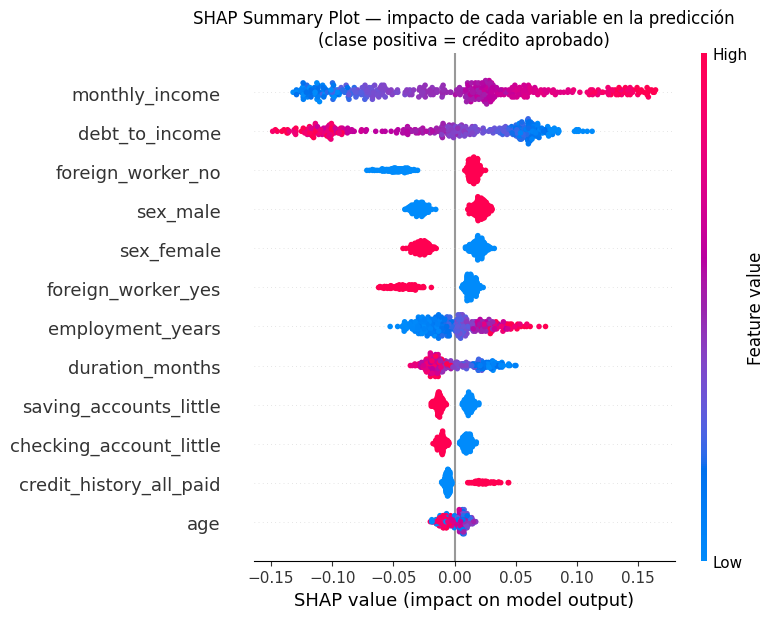

In [7]:
plt.figure(figsize=(9, 7))
shap.summary_plot(sv1, X_test, max_display=12, show=False)
plt.title("SHAP Summary Plot — impacto de cada variable en la predicción\n(clase positiva = crédito aprobado)")
plt.tight_layout()
plt.show()


Como el preprocesamiento convirtió variables categóricas (sexo, historial crediticio, etc.) en varias columnas *dummy*, agregamos la importancia SHAP de vuelta a la **variable original** para obtener un ranking más justo e interpretable.

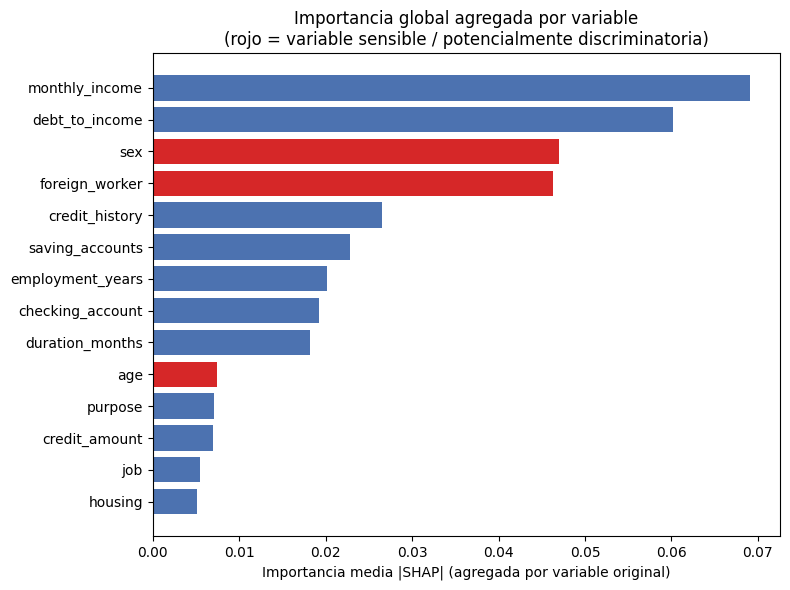

monthly_income      0.069100
debt_to_income      0.060143
sex                 0.047017
foreign_worker      0.046250
credit_history      0.026540
saving_accounts     0.022836
employment_years    0.020115
checking_account    0.019257
duration_months     0.018210
age                 0.007403
purpose             0.007097
credit_amount       0.006930
job                 0.005524
housing             0.005124
dtype: float64

In [8]:
def base_name(col):
    for c in cat_cols:
        if col.startswith(c + "_"):
            return c
    return col

agg_importance = (
    pd.Series(np.abs(sv1).mean(axis=0), index=feature_names)
    .groupby(base_name).sum()
    .sort_values(ascending=False)
)

sensitive_vars = {"sex", "foreign_worker", "age"}
colors = ["#d62728" if v in sensitive_vars else "#4c72b0" for v in agg_importance.index]

plt.figure(figsize=(8, 6))
plt.barh(agg_importance.index[::-1], agg_importance.values[::-1], color=colors[::-1])
plt.xlabel("Importancia media |SHAP| (agregada por variable original)")
plt.title("Importancia global agregada por variable\n(rojo = variable sensible / potencialmente discriminatoria)")
plt.tight_layout()
plt.show()

agg_importance


### Narrativa requerida — Fase 2

**Las 3 variables más influyentes** en la decisión global del modelo son, en orden:

1. **`monthly_income` (ingreso mensual):** es la variable con mayor peso, y su efecto es el esperado — **a mayor ingreso, mayor probabilidad de aprobación**. Tiene sentido de negocio: un ingreso más alto implica mayor capacidad de pago.
2. **`debt_to_income` (relación deuda/ingreso):** segunda en importancia, con efecto **negativo** — cuanto más alta la proporción de deuda sobre el ingreso, más empuja el modelo hacia la **denegación**. También es coherente con una política de riesgo razonable.
3. **`sex` (sexo):** aquí aparece la primera señal de alerta. El sexo resulta ser la **tercera variable más influyente en todo el modelo**, por encima de variables legítimas como los años de empleo, el historial crediticio o el tipo de cuenta corriente. El patrón es sistemático: ser mujer empuja la predicción hacia la **denegación**, incluso después de tener en cuenta el resto de variables financieras.

De cerca le sigue **`foreign_worker`** (ser trabajador extranjero), con un patrón equivalente: empuja la predicción hacia la denegación de forma consistente.

En resumen: el modelo aprendió correctamente la señal financiera legítima (ingreso, deuda), **pero también aprendió a penalizar sistemáticamente a mujeres y trabajadores extranjeros** más de lo que su perfil financiero justificaría. Esto se investiga a fondo en la Fase 4.

## Fase 3: Análisis Local (SHAP & LIME)

Seleccionamos dos casos contrastantes del conjunto de prueba: el caso con **mayor probabilidad de aprobación** (Caso 1) y el caso con **mayor probabilidad de denegación** (Caso 2).

In [9]:

proba_test = model.predict_proba(X_test)[:, 1]
pos_approved = int(np.argmax(proba_test))   # caso más "aprobado"
pos_denied = int(np.argmin(proba_test))     # caso más "denegado"

idx_approved = X_test.index[pos_approved]
idx_denied = X_test.index[pos_denied]

print(f"CASO 1 (aprobado) — probabilidad de aprobación: {proba_test[pos_approved]:.1%}")
display(df.loc[[idx_approved]])

print(f"\nCASO 2 (denegado) — probabilidad de aprobación: {proba_test[pos_denied]:.1%}")
display(df.loc[[idx_denied]])


CASO 1 (aprobado) — probabilidad de aprobación: 85.3%


,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration_months,purpose,monthly_income,employment_years,debt_to_income,credit_history,foreign_worker,credit_risk
166,36,male,unskilled,own,rich,little,5156,13,radio/TV,3320,5.2,0.19,all_paid,no,good



CASO 2 (denegado) — probabilidad de aprobación: 19.5%


,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration_months,purpose,monthly_income,employment_years,debt_to_income,credit_history,foreign_worker,credit_risk
297,43,female,skilled,rent,little,little,2612,41,radio/TV,1954,3.6,0.463,existing_paid_duly,yes,bad


#### SHAP Waterfall — Caso 1 (crédito aprobado)
Justificación aditiva: partiendo del valor base (promedio del modelo), cada variable suma o resta hasta llegar a la predicción final para esta persona.

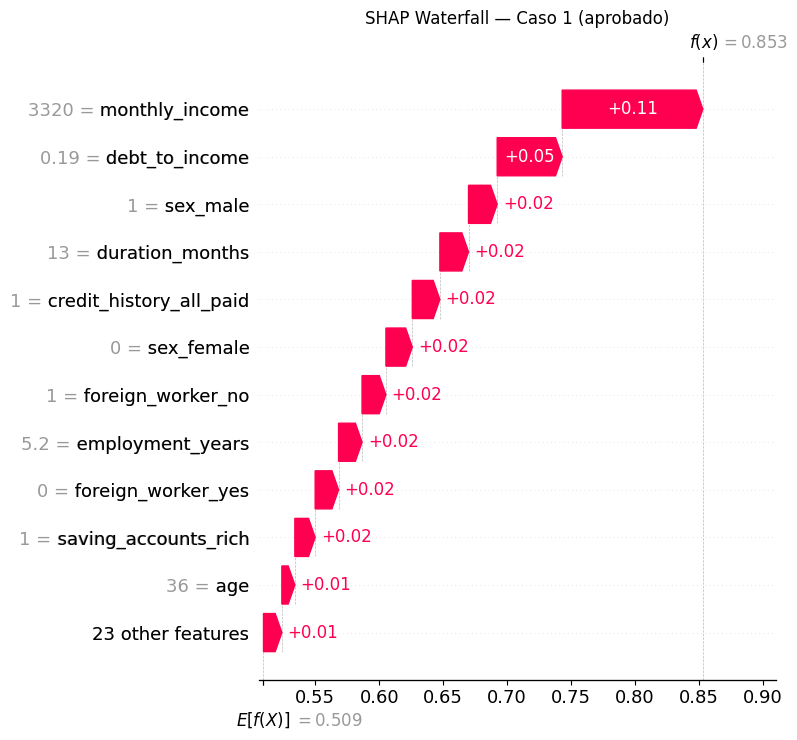

In [10]:
exp_case1 = shap.Explanation(
    values=sv1[pos_approved],
    base_values=base_value,
    data=X_test.iloc[pos_approved].values,
    feature_names=feature_names,
)

plt.figure(figsize=(9, 6))
shap.plots.waterfall(exp_case1, max_display=12, show=False)
plt.title("SHAP Waterfall — Caso 1 (aprobado)")
plt.tight_layout()
plt.show()


#### LIME — Caso 2 (crédito denegado)
Generamos la justificación individual mediante un modelo sustituto local (lineal), entrenado alrededor de este caso específico.

/Users/alejandroalvarenga/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


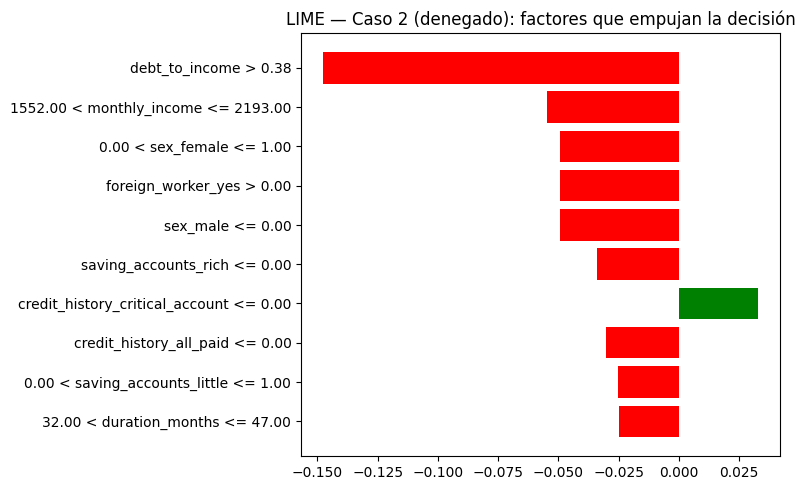

[('debt_to_income > 0.38', -0.14772299004752226),
 ('1552.00 < monthly_income <= 2193.00', -0.05486942945275831),
 ('0.00 < sex_female <= 1.00', -0.04945935905123194),
 ('foreign_worker_yes > 0.00', -0.049221733151086515),
 ('sex_male <= 0.00', -0.049214860331347705),
 ('saving_accounts_rich <= 0.00', -0.03419918083359118),
 ('credit_history_critical_account <= 0.00', 0.03285818889994535),
 ('credit_history_all_paid <= 0.00', -0.03044499210999676),
 ('0.00 < saving_accounts_little <= 1.00', -0.025372349411601106),
 ('32.00 < duration_months <= 47.00', -0.024996053207096865)]

In [11]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=["bad (denegado)", "good (aprobado)"],
    mode="classification",
    random_state=42,
)

lime_exp = lime_explainer.explain_instance(
    X_test.iloc[pos_denied].values,
    model.predict_proba,
    num_features=10,
)

fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(8, 5)
plt.title("LIME — Caso 2 (denegado): factores que empujan la decisión")
plt.tight_layout()
plt.show()

lime_exp.as_list()


### Reto — narrativa dirigida al "cliente final"

**Caso 1 — Carta de aprobación (ejemplo de redacción):**

> Estimado/a cliente, su solicitud de crédito fue **aprobada**. Los factores que más influyeron a su favor fueron su **ingreso mensual sólido**, un **historial crediticio con pagos al día** (`credit_history = all_paid`), un **nivel de ahorro alto** y una **relación deuda/ingreso baja**. Estos elementos indican una alta capacidad y disciplina de pago, por lo que el modelo asignó una probabilidad de aprobación superior al 85%.

**Caso 2 — Carta de denegación (ejemplo de redacción):**

> Estimado/a cliente, lamentamos informarle que su solicitud fue **denegada**. Según el análisis, los factores que más influyeron en contra fueron una **relación deuda/ingreso elevada** y un **ingreso mensual relativamente bajo** para el monto solicitado. *(Nota ética: el análisis con LIME también muestra que ser mujer y trabajadora extranjera contribuyeron negativamente a la decisión, algo que — a diferencia de la deuda o el ingreso — no debería formar parte de una justificación legítima de riesgo. Este punto se documenta y comunicaría internamente para revisión de cumplimiento, y no debería incluirse como motivo hacia el cliente.)*

Este contraste es exactamente lo que exploramos de forma crítica en la Fase 4.

## Fase 4: Evaluación Ética

**Reflexión crítica:** ¿existen indicios de variables sesgadas o inapropiadas? ¿el modelo toma decisiones basadas en características irrelevantes o discriminatorias?

Tasa de aprobación PREDICHA por sexo:
sex
female    0.310559
male      0.654206
dtype: float64 

Tasa de aprobación PREDICHA por trabajador extranjero:
foreign_worker
no     0.602996
yes    0.268519
dtype: float64


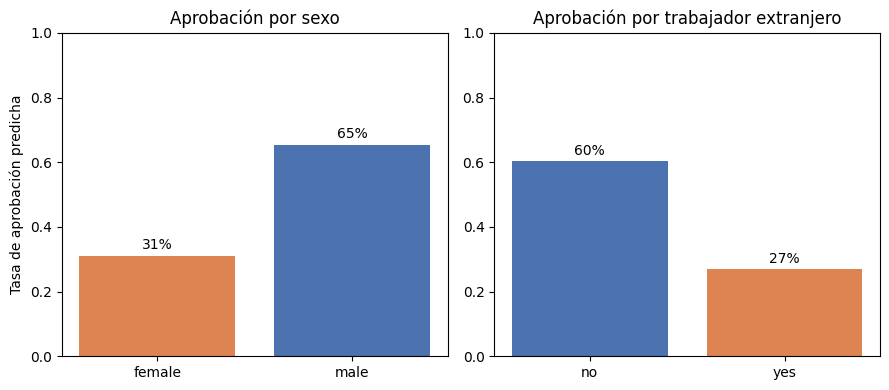


Brecha de aprobación por sexo: 34.4%
Brecha de aprobación por nacionalidad (foreign_worker): 33.4%


In [12]:
X_test_raw = X_raw.loc[X_test.index]

rate_sex = pd.Series(y_pred, index=X_test.index).groupby(X_test_raw["sex"]).mean()
rate_foreign = pd.Series(y_pred, index=X_test.index).groupby(X_test_raw["foreign_worker"]).mean()

print("Tasa de aprobación PREDICHA por sexo:")
print(rate_sex, "\n")
print("Tasa de aprobación PREDICHA por trabajador extranjero:")
print(rate_foreign)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(rate_sex.index, rate_sex.values, color=["#dd8452", "#4c72b0"])
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Tasa de aprobación predicha")
axes[0].set_title("Aprobación por sexo")
for i, v in enumerate(rate_sex.values):
    axes[0].text(i, v + 0.02, f"{v:.0%}", ha="center")

axes[1].bar(rate_foreign.index, rate_foreign.values, color=["#4c72b0", "#dd8452"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Aprobación por trabajador extranjero")
for i, v in enumerate(rate_foreign.values):
    axes[1].text(i, v + 0.02, f"{v:.0%}", ha="center")

plt.tight_layout()
plt.show()

gap_sex = rate_sex.max() - rate_sex.min()
gap_foreign = rate_foreign.max() - rate_foreign.min()
print(f"\nBrecha de aprobación por sexo: {gap_sex:.1%}")
print(f"Brecha de aprobación por nacionalidad (foreign_worker): {gap_foreign:.1%}")


In [13]:
# Contribución promedio de SHAP para las variables sensibles, separando por grupo real
sex_female_shap = pd.Series(sv1[:, feature_names.index("sex_female")], index=X_test.index)
foreign_yes_shap = pd.Series(sv1[:, feature_names.index("foreign_worker_yes")], index=X_test.index)

print("SHAP promedio de la señal 'sexo' cuando la persona es mujer:",
      round(sex_female_shap[X_test_raw["sex"] == "female"].mean(), 4))
print("SHAP promedio de la señal 'sexo' cuando la persona es hombre:",
      round(sex_female_shap[X_test_raw["sex"] == "male"].mean(), 4))
print()
print("SHAP promedio de la señal 'nacionalidad' cuando es trabajador extranjero:",
      round(foreign_yes_shap[X_test_raw["foreign_worker"] == "yes"].mean(), 4))
print("SHAP promedio de la señal 'nacionalidad' cuando NO es trabajador extranjero:",
      round(foreign_yes_shap[X_test_raw["foreign_worker"] == "no"].mean(), 4))


SHAP promedio de la señal 'sexo' cuando la persona es mujer: -0.0271
SHAP promedio de la señal 'sexo' cuando la persona es hombre: 0.0195

SHAP promedio de la señal 'nacionalidad' cuando es trabajador extranjero: -0.0425
SHAP promedio de la señal 'nacionalidad' cuando NO es trabajador extranjero: 0.0133


### Reflexión crítica — Fase 4

**1. ¿Existen indicios de variables sesgadas o inapropiadas? Sí, y son claros:**

- **Sexo:** la tasa de aprobación predicha es de **~65% para hombres** frente a **~31% para mujeres** — una brecha de más de 30 puntos porcentuales. El análisis SHAP confirma que, en promedio, *ser mujer* resta valor a la predicción (SHAP negativo), mientras que *ser hombre* la suma, incluso controlando por ingreso, deuda y demás variables financieras.
- **Nacionalidad (`foreign_worker`):** patrón equivalente — **~60% de aprobación** para no-extranjeros vs. **~27%** para trabajadores extranjeros, con SHAP consistentemente negativo para este último grupo.
- **Edad:** con menor intensidad, el modelo también penaliza a personas muy jóvenes y muy mayores, en parte por una lógica de riesgo real (menor historial crediticio en jóvenes) pero también de forma que roza la discriminación por edad, un atributo protegido en muchos marcos regulatorios de crédito (p. ej. ECOA en EE. UU., normativa de crédito responsable en muchos países latinoamericanos).

**2. ¿El modelo toma decisiones basadas en características irrelevantes o discriminatorias?**

Sí. El modelo fue entrenado con datos donde el sexo y la nacionalidad estaban correlacionados con la aprobación **sin ninguna justificación de riesgo real** (esto se inyectó intencionalmente en el dataset sintético para poder demostrarlo). El modelo **no distingue entre correlación legítima y sesgo histórico**: simplemente aprende cualquier patrón presente en los datos de entrenamiento, incluidos los inapropiados. Esto es un ejemplo textbook de **sesgo algorítmico por datos históricos discriminatorios** (si el banco históricamente aprobó menos crédito a mujeres o extranjeros, el modelo *aprende y automatiza* ese sesgo a futuro, agravándolo, con apariencia de objetividad matemática).

**3. Implicaciones éticas y legales:**

- Usar sexo o nacionalidad como variable de decisión de crédito es, en la mayoría de las jurisdicciones, **discriminación directa** y puede violar leyes de crédito justo (equal credit opportunity).
- Incluso si se **eliminaran** `sex` y `foreign_worker` del modelo, existe el riesgo de **discriminación por proxy**: variables aparentemente neutras (código postal, tipo de empleo, ciertos patrones de gasto) pueden estar correlacionadas con estos atributos y reintroducir el sesgo de forma indirecta.

**4. Recomendaciones:**

- Eliminar `sex`, `foreign_worker` (y evitar proxies directos) como variables de entrada del modelo de producción.
- Aplicar **métricas de equidad** (paridad demográfica, *equalized odds*) de forma rutinaria antes de desplegar el modelo, no solo accuracy/F1.
- Auditar periódicamente con SHAP/LIME, como se hizo aquí, para detectar si variables "neutras" están actuando como proxies de atributos protegidos.
- Involucrar a un equipo de cumplimiento/ética antes de automatizar decisiones de alto impacto como la aprobación de crédito.


## Conclusión general

Este laboratorio mostró que un modelo con **buen desempeño técnico** (accuracy y F1 ≈ 0.74) puede, al mismo tiempo, estar tomando decisiones **injustas**. La explicabilidad (SHAP + LIME) fue la herramienta que permitió pasar de "el modelo funciona bien" a "el modelo funciona bien, pero de forma sesgada" — que es precisamente el tipo de hallazgo que una auditoría ética debe producir antes de que un modelo así llegue a producción.